In [4]:
from attacks import *
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import random
import time
import copy
import pickle
from collections import Counter
import scipy
import csv
import os
from util.eval import compute_accuracy
import matplotlib.pyplot as plt
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
%matplotlib inline

In [5]:
class PurchaseClassifier(nn.Module):
    def __init__(self,num_classes=100):
        super(PurchaseClassifier, self).__init__()

        self.features = nn.Sequential(
            nn.Linear(600,1024),
            nn.Tanh(),
            nn.Linear(1024,512),
            nn.Tanh(),
            nn.Linear(512,256),
            nn.Tanh(),
            nn.Linear(256,128),
            nn.Tanh(),
        )
        self.classifier = nn.Linear(128,num_classes)
        
    def forward(self,inp):
        
        outputs=[]
        x=inp
        module_list =list(self.features.modules())[1:]
        for l in module_list:
            
            x = l(x)
            outputs.append(x)
        
        y = x.view(inp.size(0), -1)
        o = self.classifier(y)
        
        return o

class PurchaseClassifierDrop(nn.Module):
    def __init__(self, num_classes=100, dropout_rate=0.0):
        super(PurchaseClassifierDrop, self).__init__()

        # Initialize the layers of the feature extractor with dropout after activation layers
        self.features = nn.Sequential(
            nn.Linear(600, 1024),
            nn.Tanh(),
            nn.Dropout(p=dropout_rate),  # Dropout after first activation
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Dropout(p=dropout_rate),  # Dropout after second activation
            nn.Linear(512, 256),
            nn.Tanh(),
            nn.Dropout(p=dropout_rate),  # Dropout after third activation
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Dropout(p=dropout_rate)   # Dropout after fourth activation
        )
        self.classifier = nn.Linear(128, num_classes)
        
    def forward(self, inp):
        outputs = []
        x = inp
        # Iterate through all modules in the features to capture intermediate outputs
        for l in self.features:
            x = l(x)
            outputs.append(x)
        
        # Flatten the output from the last layer and pass it through the classifier
        y = x.view(inp.size(0), -1)
        o = self.classifier(y)
        
        # Return the final output, and the last and fourth-last intermediate outputs
        return o

In [7]:
model=PurchaseClassifier()
params = sum(p.numel() for p in model.parameters())
params

1317348

In [3]:
import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning

# Filter out ConvergenceWarning and FitFailedWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
print("Loading data...", flush=True)
data_set= np.load('./purchase.npy')
X = data_set[:,1:].astype(np.float64)
Y = (data_set[:,0]).astype(np.int32)-1

n_data = len(Y)
print('Total number of data points: ',n_data, flush=True)

n_train_data = int(n_data * 0.8) 
n_val_data = int(n_data * 0.2)
n_test_data = int(n_data * 0.2) 

if not os.path.isfile('./purchase_shuffle.pkl'):
    all_indices = np.arange(n_data)
    np.random.shuffle(all_indices)
    pickle.dump(all_indices,open('./purchase_shuffle.pkl','wb'))
else:
    all_indices=pickle.load(open('./purchase_shuffle.pkl','rb'))

# Sample train, val and test sets from  the whole data
train_inputs = X[all_indices[:n_train_data]]
train_labels=Y[all_indices[:n_train_data]]
test_inputs = X[all_indices[n_train_data:]]
test_labels = Y[all_indices[n_train_data:]]

train_inputs = torch.from_numpy(train_inputs).type(torch.FloatTensor)
train_labels = torch.from_numpy(train_labels).type(torch.LongTensor)
test_inputs = torch.from_numpy(test_inputs).type(torch.FloatTensor)
test_labels = torch.from_numpy(test_labels).type(torch.LongTensor)

print('Trainset len %d | Valset len %d Testset len %d'% (n_train_data, n_val_data, n_test_data), flush=True)


# Create TensorDatasets
train_dataset = TensorDataset(torch.tensor(train_inputs, dtype=torch.float32), torch.tensor(train_labels, dtype=torch.int64))
test_dataset = TensorDataset(torch.tensor(test_inputs, dtype=torch.float32), torch.tensor(test_labels, dtype=torch.int64))

# Create DataLoader instances
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('Trainset len %d | Testset len %d'% (n_train_data, n_test_data), flush=True)

Loading data...
Total number of data points:  197324
Trainset len 157859 | Valset len 39464 Testset len 39464
Trainset len 157859 | Testset len 39464


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=PurchaseClassifier()
# model=PurchaseClassifierDrop()
# model = ModuleValidator.fix(model)
# ModuleValidator.validate(model, strict=False)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.0005, momentum=0.9)
# privacy_engine = PrivacyEngine()
# model, optimizer, data_loader = privacy_engine.make_private(
#     module=model,
#     optimizer=optimizer,
#     data_loader=train_loader,
#     noise_multiplier=1.0,
#     max_grad_norm=1.0,
# ) 
model.to(device)
criterion = nn.CrossEntropyLoss()
checkpoint_dir='./checkpoints_reg/model_epoch100_wd0.0050.t7'

#     checkpoint = torch.load(os.path.join(checkpoint_dir, 'model_{}.t7'.format(t)))
checkpoint = torch.load(checkpoint_dir)
for k in checkpoint.keys():
    if  'time' in k:
        print(k, ":", checkpoint[k])
model.load_state_dict(checkpoint['state_dict'])

logits_test, loss_test, test_labels, test_preds = compute_attack_components(model, test_loader)
logits_train, loss_train, train_labels, train_preds = compute_attack_components(model, train_loader)

train_acc, train_probs = compute_accuracy(logits_train, train_labels)
print('Train Acc:{:0.2f}%'.format(train_acc*100))
test_acc, test_probs = compute_accuracy(logits_test, test_labels)
print('Test Acc:{:0.2f}%'.format(test_acc*100))

attack_result = tf_attack(logits_train, logits_test, loss_train, loss_test, 
                      train_labels, test_labels)
auc = attack_result.get_result_with_max_auc().get_auc()
adv = attack_result.get_result_with_max_attacker_advantage().get_attacker_advantage()
print('AUC:{:0.2f}%'.format(100.0*auc))
print('Advantage:{:0.2f}%'.format(100.0*adv))
print('------------------------')

time : 813.4898235797882
Train Acc:77.76%
Test Acc:76.16%
AUC:50.92%
Advantage:1.73%
------------------------


In [8]:
# Be exceptionally careful.
# Numerically stable everything, as described in the paper.
predictions = logits_train - np.max(logits_train, axis=-1, keepdims=True)
predictions = np.array(np.exp(predictions), dtype=np.float64)
predictions = predictions / np.sum(predictions, axis=-1, keepdims=True)

labels = train_labels  # TODO generalize this

COUNT = predictions.shape[0]
y_true = predictions[np.arange(COUNT), labels[:COUNT]]

predictions[np.arange(COUNT), labels[:COUNT]] = 0
y_wrong = np.sum(predictions, axis=-1)

logit_train = np.log(y_true + 1e-45) - np.log(y_wrong + 1e-45) 
    
# Be exceptionally careful.
# Numerically stable everything, as described in the paper.
predictions = logits_test - np.max(logits_test, axis=-1, keepdims=True)
predictions = np.array(np.exp(predictions), dtype=np.float64)
predictions = predictions / np.sum(predictions, axis=-1, keepdims=True)

labels = test_labels  # TODO generalize this

COUNT = predictions.shape[0]
y_true = predictions[np.arange(COUNT), labels[:COUNT]]

predictions[np.arange(COUNT), labels[:COUNT]] = 0
y_wrong = np.sum(predictions, axis=-1)

logit_test = np.log(y_true + 1e-45) - np.log(y_wrong + 1e-45)

thresh = np.percentile(logit_test, 99)
tpr = (logit_train >= thresh).mean()
fpr = (logit_test >= thresh).mean()
print(tpr*100, fpr*100)

1.151027182485636 1.0008868617762574


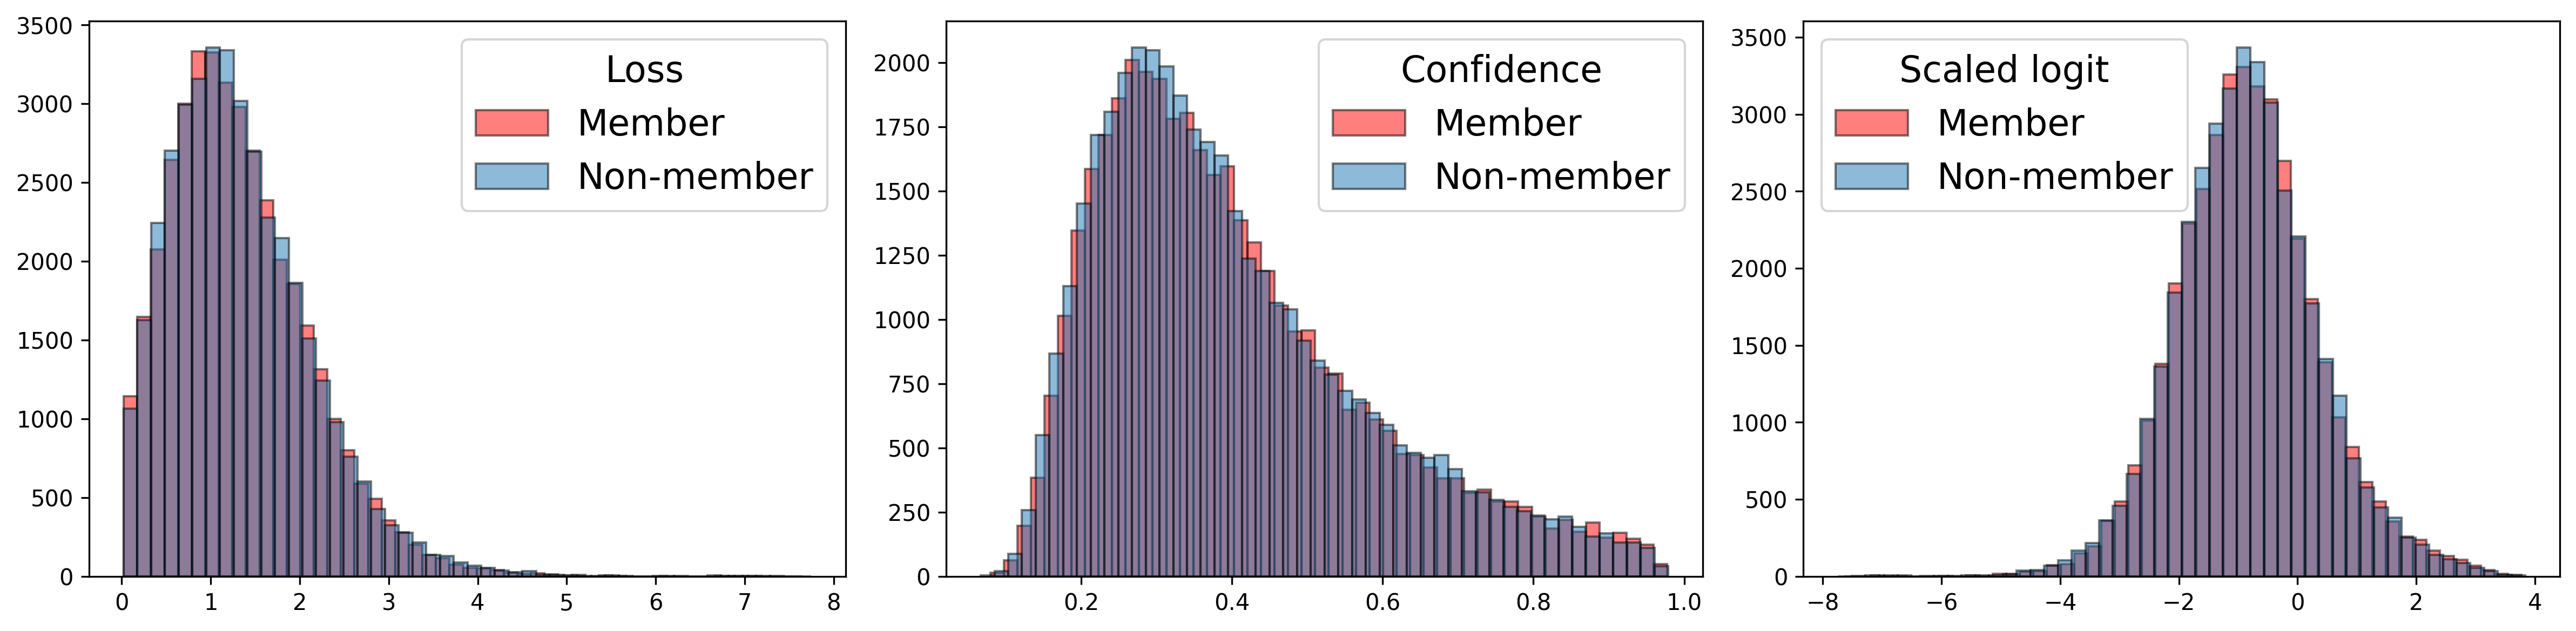

In [9]:
# Define figure size and dpi
figsize = (16, 4)
dpi = 300
legend_fontsize = 16

# Create a figure with three subplots in one row
fig, axes = plt.subplots(1, 3, figsize=figsize, dpi=dpi)

# Plot for loss
idxs = np.random.choice(len(train_labels), len(test_labels), replace = False)
axes[0].hist(loss_train[idxs], bins=50, alpha=0.5, label='Member', color='red', edgecolor='black')
axes[0].hist(loss_test, bins=50, alpha=0.5, label='Non-member', edgecolor='black')
axes[0].legend(loc='best', title='Loss', fontsize=legend_fontsize, title_fontsize=legend_fontsize)


# Plot for confidence
axes[1].hist(train_probs[idxs].max(axis=-1), bins=50, alpha=0.5, label='Member', color='red', edgecolor='black')
axes[1].hist(test_probs.max(axis=-1), bins=50, alpha=0.5, label='Non-member', edgecolor='black')
axes[1].legend(loc='best', title='Confidence', fontsize=legend_fontsize, title_fontsize=legend_fontsize)


# Plot for scaled logit
axes[2].hist(logit_train[idxs], bins=50, alpha=0.5, label='Member', color='red', edgecolor='black')
axes[2].hist(logit_test, bins=50, alpha=0.5, label='Non-member', edgecolor='black')
axes[2].legend(loc='best', title='Scaled logit', fontsize=legend_fontsize, title_fontsize=legend_fontsize)


# Adjust layout
plt.tight_layout()
plt.savefig('figures/purchse_lcl_dp.png', bbox_inches='tight')
# Show the plot
plt.show()


In [ ]:
# # Our Defense

# classes = set(train_labels)
# class_cl = {c: None for c in classes}
# for c in class_cl:
#     print('Class:', c)
#     idxs_c = np.where(train_labels == c)[0]
#     logits_c = logits_train[idxs_c]
#     centroid = np.mean(logits_c, axis = 0)
#     class_cl[c] = centroid
    
# for c in class_cl:
#     centroid = class_cl[c]
    
#     idxs_c = np.where(train_preds == c)[0]
#     logits_train[idxs_c] = centroid
    
#     idxs_c = np.where(test_preds == c)[0]
#     logits_test[idxs_c] = centroid

# print('Defended train Acc:{:0.2f}%'.format(compute_accuracy(logits_train, train_labels)*100))
# print('Defended test Acc:{:0.2f}%'.format(compute_accuracy(logits_test, test_labels)*100))

# criterion = nn.CrossEntropyLoss(reduction='none')
# defended_train_loss = criterion(torch.from_numpy(logits_train), torch.from_numpy(train_labels))
# defended_test_loss = criterion(torch.from_numpy(logits_test), torch.from_numpy(test_labels))

# attack_result = tf_attack(logits_train, logits_test, defended_train_loss.numpy(), defended_test_loss.numpy(), 
#                           train_labels, test_labels)
# auc = attack_result.get_result_with_max_auc().get_auc()
# adv = attack_result.get_result_with_max_attacker_advantage().get_attacker_advantage()

# print('AUC:{:0.2f}%'.format(100.0*auc))
# print('Advantage:{:0.2f}%'.format(100.0*adv))
# print('------------------------')

# plt.figure(figsize=(10, 6))

# # Plot histogram for loss_test
# plt.hist(defended_test_loss, bins=30, alpha=0.5, label='Loss Test')

# # Plot histogram for loss_train
# plt.hist(defended_train_loss, bins=30, alpha=0.5, label='Loss Train')

# # Add labels and title
# plt.xlabel('Loss')
# plt.ylabel('Frequency')
# plt.title('Histograms of Loss Test and Loss Train')

# # Add legend
# plt.legend(loc='upper right')

# # Show the plot
# plt.show()